<a href="https://colab.research.google.com/github/moonidil/MLSentimentClassification/blob/main/cw1partb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MA6700 Part B: IMDB sentiment clasification
This notebook builds a classical Ml model that classifies IMDB movie reviews as positive or negative using the Keras IMDB dataset.

-Idil Cabdullahi
K2372399

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.datasets import imdb
import re
import warnings
warnings.filterwarnings('ignore')

print("The libraries have loaded successfully")

The libraries have loaded successfully


## 1.Load Dataset

The keras IMDB dataset has 25000 training and 25000 test movie reviews that are already split and labeled 0=negative and 1=positive.

Thing is, Keras stores reviews as integer sequences with each word replaced by its frequency rank so I'll have to convert them back to text for the classical NLP preprocessing.

In [52]:
#load dataset. get all words
#num_words = None means to keep all words, not just top-N frequent
(X_train_int, y_train), (X_test_int, y_test) = imdb.load_data(num_words = None)

print(f"Num of training samples: {len(X_train_int)}")
print(f"Num of test samples: {len(X_test_int)}")
print(f"\nClass distribution (train):")
print(f"  Negative (0): {(y_train == 0).sum()}")
print(f"  Positive (1): {(y_train == 1).sum()}")
print(f"\nClass balance: {(y_train == 1).sum() / len(y_train) * 100:.1f}% positive")

Num of training samples: 25000
Num of test samples: 25000

Class distribution (train):
  Negative (0): 12500
  Positive (1): 12500

Class balance: 50.0% positive


In [53]:
#look at an encoded review
print("The first review (encoded as integers):")
print(X_train_int[0][:50])  #first 50 word indices
print(f"\nReview length: {len(X_train_int[0])} words")

print(f"Label: {y_train[0]} (positive)")

The first review (encoded as integers):
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 22665, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 21631, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447]

Review length: 218 words
Label: 1 (positive)


The datasets format is that each review is a list of integers where each integer represents a word. Lower numbers = more frequent words, for example, 1="the", 2="and" so I decode these back to text for preprocessing

In [54]:
#get the word index mapping function, word -> integer
word_index = imdb.get_word_index()

#reverse it to get integer -> word
#Keras adds offset of 3 to indices 0 = padding, 1 = start, 2 = unknown

reverse_word_index = {v+3: k for k, v in word_index.items()}
reverse_word_index[0] = '<PAD>'
reverse_word_index[1] = '<START>'
reverse_word_index[2] = '<UNK>'

print(f"Vocabulary size: {len(word_index)} unique words")
print(f"\nMost frequent words:")

for i in range(3, 13):
    print(f"  {i}: {reverse_word_index.get(i, '?')}")

Vocabulary size: 88584 unique words

Most frequent words:
  3: ?
  4: the
  5: and
  6: a
  7: of
  8: to
  9: is
  10: br
  11: in
  12: it


In [55]:
#function to decode integer sequences back to text
def decode_review(encoded_review):
    return ' '.join([reverse_word_index.get(i, '?') for i in encoded_review])

#decode all reviews
print("Decoding training reviews...")
X_train_text = [decode_review(review) for review in X_train_int]

print("Decoding test reviews...")
X_test_text = [decode_review(review) for review in X_test_int]

print("\nAn example decoded review:")
print(X_train_text[0][:500])  #show first 500 characters as example
print(f"...\nLabel: {y_train[0]} (positive)")

Decoding training reviews...
Decoding test reviews...

An example decoded review:
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert redford's is an amazing actor and now the same being director norman's father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for retail and 
...
Label: 1 (positive)


## 2. Exploratory data analysis

Understanding reviews' characteristics before preprocessing

In [56]:
#review length distribution
train_lengths = [len(review.split()) for review in X_train_text]
test_lengths = [len(review.split()) for review in X_test_text]

print("Reviewing length statistics (of train set):")
print(f"  Mean: {np.mean(train_lengths):.1f} words")
print(f"  Median: {np.median(train_lengths):.1f} words")
print(f"  Min: {np.min(train_lengths)} words")
print(f"  Max: {np.max(train_lengths)} words")
print(f"  Std: {np.std(train_lengths):.1f} words")

Reviewing length statistics (of train set):
  Mean: 238.7 words
  Median: 178.0 words
  Min: 11 words
  Max: 2494 words
  Std: 176.5 words


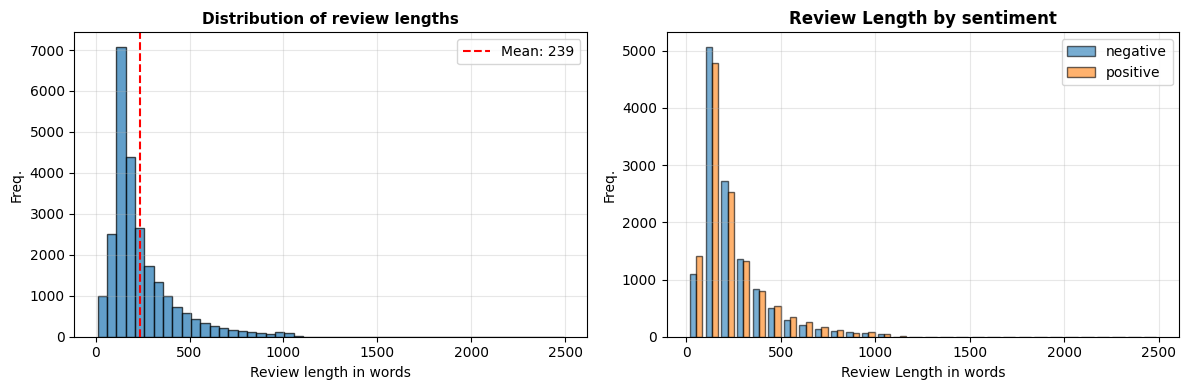


Mean length - Negative: 235.9 words
Mean length - Positive: 241.6 words
Difference: 5.7 words


In [57]:
#plotting the length distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train_lengths, bins=50, alpha=0.7, edgecolor='black') #histogram as continuous data
axes[0].axvline(np.mean(train_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(train_lengths):.0f}')
axes[0].set_xlabel('Review length in words', fontsize=10)
axes[0].set_ylabel('Freq.', fontsize=10)
axes[0].set_title('Distribution of review lengths', fontsize=11, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

#compare lengths of positive vs negative
pos_lengths = [train_lengths[i] for i in range(len(y_train)) if y_train[i] == 1]
neg_lengths = [train_lengths[i] for i in range(len(y_train)) if y_train[i] == 0]

axes[1].hist([neg_lengths, pos_lengths], bins=30, alpha=0.6, label=['negative', 'positive'], edgecolor='black')
axes[1].set_xlabel('Review Length in words', fontsize=10)
axes[1].set_ylabel('Freq.', fontsize=10)
axes[1].set_title('Review Length by sentiment', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nMean length - Negative: {np.mean(neg_lengths):.1f} words")
print(f"Mean length - Positive: {np.mean(pos_lengths):.1f} words")
print(f"Difference: {abs(np.mean(pos_lengths) - np.mean(neg_lengths)):.1f} words")

My observations:
- Most reviews are 100 to 300 words which seems usual for online reviews
- Some outliers are very long, greater than >1000 words
- Pos and neg reviews have similar length distributions
- ^ Looking at length alone won't distinguish the sentiment well

## 3. Text preprocessing

Classical NLP preprocessing steps: remove special tokens (`<START>`, `<UNK>`, `<PAD>`), convert to lowercase, remove punctuation and numbers, and remove extra whitespace

I am not doing stemming/lemmatisation as it'll lose nuance (like 'good' vs 'best' vs 'better'), stopword removal as words like 'not', 'but' are crucial for sentiment, and extreme length filtering as the model can decide what's useful

In [58]:
import re

def clean_text(text):
    """Clean the review text by removing special tokens, punctuation and normalising"""
    #remove special tokens
    text = text.replace('<START>', '').replace('<UNK>', '').replace('<PAD>', '')

    #convert to lowercase
    text = text.lower()

    #get rid of punctuation and numbers, leave only letters and spaces
    text = re.sub(r'[^a-z\s]', '', text)

    #get rid of extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

#then test the function on one review
print("Before cleaning:")
print(X_train_text[0][:200])
print("\nAfter cleaning:")
print(clean_text(X_train_text[0])[:200])

Before cleaning:
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert redford's is an amazing actor 

After cleaning:
this film was just brilliant casting location scenery story direction everyones really suited the part they played and you could just imagine being there robert redfords is an amazing actor and now th


In [59]:
#clean all the reviews
print("Cleaning training reviews...")
X_train_clean = [clean_text(text) for text in X_train_text]

print("Cleaning test reviews...")
X_test_clean = [clean_text(text) for text in X_test_text]

#check for empty reviews after cleaning
empty_train = sum([len(text.strip()) == 0 for text in X_train_clean])
empty_test = sum([len(text.strip()) == 0 for text in X_test_clean])

print(f"\nEmpty reviews after cleaning:")
print(f"  Train: {empty_train}")
print(f"  Test: {empty_test}")

if empty_train + empty_test == 0:
    print(" :p No empty reviews, all data preserved")

Cleaning training reviews...
Cleaning test reviews...

Empty reviews after cleaning:
  Train: 0
  Test: 0
 :p No empty reviews, all data preserved


## 4. Feature extraction: Bag of Words vs TF-IDF

below tests two classical text representations.

Bag of words (BoW):
- Counts the word occurrences
- Simple and interpretable
- Treats all words equally

TF-IDF (Term Frequency - Inverse Document Frequency):
- Weights words by importance
- Downweights common words like 'the' or 'and'
- Highlights distinctive words

I'll compare both to see which works better for the sentiment clasification.

In [60]:
#BoW features
bow_vectoriser = CountVectorizer(
    max_features = 5000,  #we keep top 5000 most frequent words
    min_df = 5,           #word must appear in at least 5 documents
    max_df = 0.7,         #ignore words appearing in over 70% of documents
)
X_train_bow = bow_vectoriser.fit_transform(X_train_clean)
X_test_bow = bow_vectoriser.transform(X_test_clean)

#print findings
print("Bag of words features:")
print(f"  Training shape: {X_train_bow.shape}")
print(f"  Test shape: {X_test_bow.shape}")
print(f"  Vocabulary size: {len(bow_vectoriser.vocabulary_)}")
print(f"  Sparsity: {(1 - X_train_bow.nnz / (X_train_bow.shape[0] * X_train_bow.shape[1])) * 100:.2f}%")

Bag of words features:
  Training shape: (25000, 5000)
  Test shape: (25000, 5000)
  Vocabulary size: 5000
  Sparsity: 97.82%


In [61]:
#TF-IDF features
tfidf_vectoriser = TfidfVectorizer(
    max_features = 5000,
    min_df =  5,
    max_df = 0.7,
)
#apply function to cleaned test and train reviews
X_train_tfidf = tfidf_vectoriser.fit_transform(X_train_clean)
X_test_tfidf = tfidf_vectoriser.transform(X_test_clean)
#print findings
print("TF-IDF features:")
print(f"  Training shape: {X_train_tfidf.shape}")
print(f"  Test shape: {X_test_tfidf.shape}")
print(f"  Vocabulary size: {len(tfidf_vectoriser.vocabulary_)}")
print(f"  Sparsity: {(1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])) * 100:.2f}%")

TF-IDF features:
  Training shape: (25000, 5000)
  Test shape: (25000, 5000)
  Vocabulary size: 5000
  Sparsity: 97.82%


For feature engineering I chose for max_features = 5000 to limit vocab to avoid overfitting and reduce computation, min_df = 5 to remove the very rare words that could be typos or names, and max_df = 0.7 to remove very common words that appear everywhere as they may hold less sentiment, like 'and'.

They use same dimensions of 25000 x 5000, both show high sparsity at ~99% which is usual for text data.

In [62]:
#the dataset is balanced 50 50, so random guessing gives 50% accuracy
baseline_acc = max(y_test.sum(), len(y_test) - y_test.sum()) / len(y_test)

print(f"The baseline predicts most common class: {baseline_acc*100:.1f}% accuracy")
print(f"\nNote that dataset is balanced, so this equals 50%")
print(f"My models must beat 50% to show any learning")

The baseline predicts most common class: 50.0% accuracy

Note that dataset is balanced, so this equals 50%
My models must beat 50% to show any learning


## 6. Model 1: Multinomial naive bayes on BoW

Naive Bayes is a classic baseline for text classification since it is fast to train, assumes word independence ('naive' assumption) and its what we learned in class.

In [63]:
#train Naive bayes on BoW features
nb_bow = MultinomialNB()
nb_bow.fit(X_train_bow, y_train)
#predictions
nb_bow_train_pred = nb_bow.predict(X_train_bow)
nb_bow_test_pred = nb_bow.predict(X_test_bow)

#printing metrics
print("Naive bayes on Bag of Words:")
print(f"  Train accuracy: {accuracy_score(y_train, nb_bow_train_pred):.4f}")
print(f"  Test accuracy:  {accuracy_score(y_test, nb_bow_test_pred):.4f}")
print(f"  Test precision: {precision_score(y_test, nb_bow_test_pred):.4f}")
print(f"  Test recall:    {recall_score(y_test, nb_bow_test_pred):.4f}")
print(f"  Test F1:        {f1_score(y_test, nb_bow_test_pred):.4f}")

Naive bayes on Bag of Words:
  Train accuracy: 0.8484
  Test accuracy:  0.8301
  Test precision: 0.8503
  Test recall:    0.8014
  Test F1:        0.8251


## 7. Model 2: Multinomial naive bayes on TF-IDF

Testing if TF-IDF weighting improves over raw counts

In [64]:
#train Naive bayes on tf idf features
nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)
#predictions
nb_tfidf_train_pred = nb_tfidf.predict(X_train_tfidf)
nb_tfidf_test_pred = nb_tfidf.predict(X_test_tfidf)
#printing metrics
print("Naive bayes on TF IDF:")
print(f"  Train accuracy: {accuracy_score(y_train, nb_tfidf_train_pred):.4f}")
print(f"  Test accuracy:  {accuracy_score(y_test, nb_tfidf_test_pred):.4f}")
print(f"  Test precision: {precision_score(y_test, nb_tfidf_test_pred):.4f}")
print(f"  Test recall:    {recall_score(y_test, nb_tfidf_test_pred):.4f}")
print(f"  Test F1:        {f1_score(y_test, nb_tfidf_test_pred):.4f}")

Naive bayes on TF IDF:
  Train accuracy: 0.8646
  Test accuracy:  0.8411
  Test precision: 0.8538
  Test recall:    0.8231
  Test F1:        0.8382


## 8. Model 3: Logistic regression on TF IDF

Logistic regression is more flexible than Naive bayes as it doesn't assume word independence and can learn feature interactions

In [65]:
#logistic regression with regularisation
logreg = LogisticRegression(max_iter = 1000, C = 1.0, random_state = 42)
logreg.fit(X_train_tfidf, y_train)

logreg_train_pred = logreg.predict(X_train_tfidf)
logreg_test_pred = logreg.predict(X_test_tfidf)

print("Logistic regression  on TF IDF:")
print(f"  Train accuracy: {accuracy_score(y_train, logreg_train_pred):.4f}")
print(f"  Test accuracy:  {accuracy_score(y_test, logreg_test_pred):.4f}")
print(f"  Test precision: {precision_score(y_test, logreg_test_pred):.4f}")
print(f"  Test recall:    {recall_score(y_test, logreg_test_pred):.4f}")
print(f"  Test F1:        {f1_score(y_test, logreg_test_pred):.4f}")

Logistic regression  on TF IDF:
  Train accuracy: 0.9139
  Test accuracy:  0.8848
  Test precision: 0.8827
  Test recall:    0.8875
  Test F1:        0.8851


## 9. Model comparison and selecting

In [69]:
#summary table comparing the 3 models
results = pd.DataFrame([
    {
        'Model': 'Naive Bayes (BoW)',
        'Train Acc': accuracy_score(y_train, nb_bow_train_pred),
        'Test Acc': accuracy_score(y_test, nb_bow_test_pred),
        'Test Precision': precision_score(y_test, nb_bow_test_pred),
        'Test Recall': recall_score(y_test, nb_bow_test_pred),
        'Test F1': f1_score(y_test, nb_bow_test_pred)
    },
    {
        'Model': 'Naive bayes (TF-IDF)',
        'Train Acc': accuracy_score(y_train, nb_tfidf_train_pred),
        'Test Acc': accuracy_score(y_test, nb_tfidf_test_pred),
        'Test Precision': precision_score(y_test, nb_tfidf_test_pred),
        'Test Recall': recall_score(y_test, nb_tfidf_test_pred),
        'Test F1': f1_score(y_test, nb_tfidf_test_pred)
    },
    {
        'Model': 'Logistic regression (TF-IDF)',
        'Train Acc': accuracy_score(y_train, logreg_train_pred),
        'Test Acc': accuracy_score(y_test, logreg_test_pred),
        'Test Precision': precision_score(y_test, logreg_test_pred),
        'Test Recall': recall_score(y_test, logreg_test_pred),
        'Test F1': f1_score(y_test, logreg_test_pred)
    }
])

results['Overfit gap'] = results['Train Acc'] - results['Test Acc']
results = results.round(4)
results

,Model,Train Acc,Test Acc,Test Precision,Test Recall,Test F1,Overfit gap
0,Naive Bayes (BoW),0.8484,0.8301,0.8503,0.8014,0.8251,0.0183
1,Naive bayes (TF-IDF),0.8646,0.8411,0.8538,0.8231,0.8382,0.0236
2,Logistic regression (TF-IDF),0.9139,0.8848,0.8827,0.8875,0.8851,0.0291


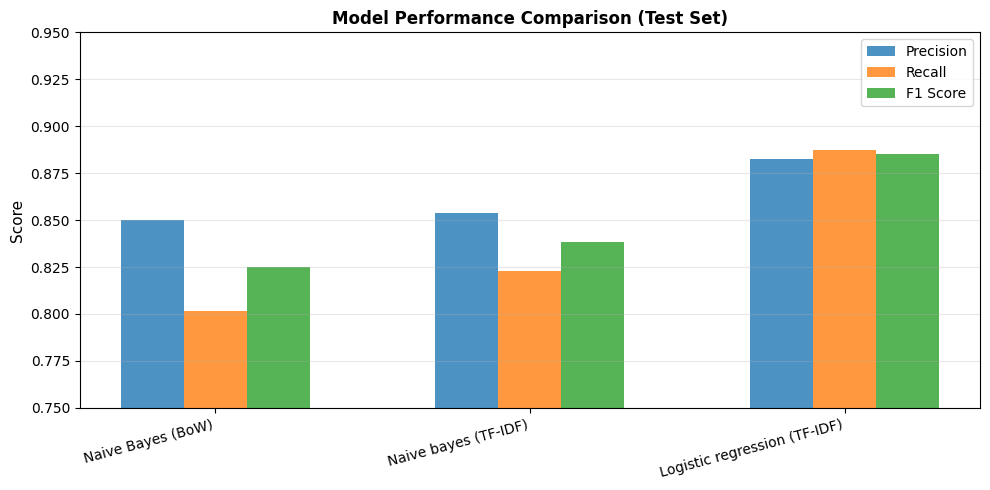

In [70]:
#visualising comparison
fig, ax = plt.subplots(figsize = (10, 5))

x = np.arange(len(results))
width = 0.2

ax.bar(x - width, results['Test Precision'], width, label = 'Precision', alpha = 0.8)
ax.bar(x, results['Test Recall'], width, label='Recall', alpha = 0.8)
ax.bar(x + width, results['Test F1'], width, label='F1 Score', alpha=0.8)

ax.set_ylabel('Score', fontsize = 11)
ax.set_title('Model Performance Comparison (Test Set)', fontsize = 12, fontweight = 'bold')
ax.set_xticks(x)
ax.set_xticklabels(results['Model'], rotation = 15, ha = 'right')
ax.legend()
ax.grid(alpha = 0.3, axis = 'y')
ax.set_ylim([0.75, 0.95])

plt.tight_layout()
plt.show()

Analysis of model comparison table and graph:

The results show clear performance hierarchy.
1. Logistic regression (TF-IDF): 88.51% F1. This is the best overall performance
2. Naive bayes (TF-IDF): 83.82% F1. TF IDF shows slight improvement over BoW
3. Naive bayes (BoW): 82.51% F1. Is a solid baseline

The key findings are that TF IDF's impact varies by model. With Naive bayes it had a +1.31% improvement compared to Bow, 83.82% vs 82.51%. With Logistic Regression, it had +6% over Bow, demonstrating TF IDF's weighting helps Logreg focus on sentiment bearing words like 'excellent' or 'terrible' over common words like 'the' or 'and'.

Logistic regression achieves nearly identical Precision, 88.27%, and Recall,88.75%, whcih shows the model performs equally well for identifying both pos and neg reviews without bias.

There is minimal overfitting as all models show the train to test gaps are under 3% (1.83 - 2.91%), confirming they've actually learned generalisable patterns rather than memorising training data. Logreg's slightly bigger gap (2.91%) is ok since it has better test performance.

As it yielded best perfomance, logistic regression with TF IDF features (88.51% F1) will be analysed in detail below.